# 16 — Reconstruction-Residual Anomaly Maps (the LOO χ engine)

**What this notebook is.** The Week-1 sanity check from
[`docs/sufficiency_anomaly_head_design.md`](../docs/sufficiency_anomaly_head_design.md):
turn the frozen v10 foundation's *leave-one-band-out (LOO) reconstruction residual*
into a **noise-normalized anomaly map**, with **no training** — pure inference on a
checkpoint we already have.

**The one idea.** The foundation was trained by masking one band and reconstructing
it from the other nine. At inference we replay that: mask band *b*, predict it from
the rest, and look at where the prediction *fails*. A large, spatially-correlated
failure means the 9 jointly-calibrated bands cannot explain band *b* there — i.e.
reality departs from the model. That is exactly an anomaly score: it flags
instrumental systematics (spikes, persistence, chip edges, trails) **and** genuine
surprises (blends, lenses, mergers, variability), and it doubles as an
OOD/transfer-failure detector.

**Why the residual is already in the right units (this is the crucial point).**
In `JAISPFoundationV10.forward()` the network does not predict raw flux — it predicts
the *noise-normalized* image

$$\text{target\_norm} = \frac{\text{image}}{\text{rms}} = \frac{\text{flux}}{\sigma}.$$

So the returned residual

$$r_b \;=\; \text{pred} - \text{target\_norm} \;=\; \frac{f^{\text{model}}_b - f^{\text{data}}_b}{\sigma_b}$$

is a **per-pixel χ map** — flux residual in units of the per-pixel noise σ.
No extra normalization is needed; the RMS maps stored in each tile's `var` array
(or the MAD fallback for var-less EDF-S tiles) do the work. This is the same
`resid = pred - truth` the trainer already computes for its W&B panels
(`train_jaisp_foundation_v10.py`, eval loop ~L727–741); we are promoting it from a
diagnostic to a science product.

**What we check here (the three gates the design doc demands):**
1. **Calibration:** on blank sky a *perfect* model leaves only unpredictable noise, so
   the χ map must be ≈ 𝒩(0, 1). If it isn't, the score isn't interpretable.
2. **Within-instrument anomalies fire:** diffraction spikes / chip edges / saturated
   cores should light up as correlated high-|χ| structure.
3. **Cross-instrument channel:** masking a *whole instrument* (predict Euclid VIS from
   the 6 Rubin bands) isolates the cross-instrument inconsistency that the science
   targets (resolution/morphology-driven surprises) live in.

Everything below is read-only on the frozen checkpoint
`models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt`.

## 0. Setup

We add `../models` to the path (this notebook lives in `io/`), load the frozen v10
foundation, and pick a device. Nothing here trains or writes weights.

In [1]:
import sys, os
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

REPO = Path.cwd().parent if Path.cwd().name == "io" else Path.cwd()
MODELS = REPO / "models"
sys.path.insert(0, str(MODELS))          # so `import jaisp_foundation_v10` works
sys.path.insert(0, str(REPO))

from load_foundation import load_foundation
from jaisp_dataset_v10 import JAISPDatasetV10, ALL_BANDS, RUBIN_BANDS, EUCLID_BANDS

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
CKPT = REPO / "models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt"
print("repo  :", REPO)
print("device:", device)
print("ckpt  :", CKPT.exists(), CKPT)

repo  : /home/shemmati/Work/Projects/JAISP
device: cuda:0
ckpt  : True /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt


In [2]:
# Load the frozen foundation once. freeze=True sets eval() + requires_grad=False.
model = load_foundation(str(CKPT), device=device, freeze=True)
n_params = sum(p.numel() for p in model.parameters())
print(f"loaded foundation: {n_params/1e6:.1f}M params, training={model.training}")

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
loaded foundation: 9.2M params, training=False


## 1. Load one fully-populated 10-band tile

`JAISPDatasetV10` returns a per-tile dict of `{band: {'image':[1,H,W], 'rms':[1,H,W]}}`.
We disable augmentation (`augment=False`) so pixel coordinates stay aligned with the
detection catalog, and we keep the **full native tiles** (no random crop) — Rubin
512×512 at 0.2″/px, Euclid ~1084×1084 at 0.1″/px.

We scan for a tile that has all 10 bands so every LOO channel is available.

In [3]:
ds = JAISPDatasetV10(
    rubin_dir=str(REPO / "data/rubin_tiles_200"),
    euclid_dir=str(REPO / "data/euclid_tiles_200"),
    load_euclid=True,
    augment=False,      # keep coords aligned with detection catalog
    mmap=True,
)

def pool_of(sample):
    p = {}; p.update(sample.get("rubin", {})); p.update(sample.get("euclid", {}))
    return p

# Find the first tile with the full 10-band complement.
tile_idx, sample, pool = None, None, None
for i in range(len(ds)):
    s = ds[i]
    p = pool_of(s)
    if len(p) == len(ALL_BANDS):
        tile_idx, sample, pool = i, s, p
        break

assert sample is not None, "no fully-populated 10-band tile found"
print("tile_idx :", tile_idx)
print("tile_id  :", sample["tile_id"])
print("bands    :", [b for b in ALL_BANDS if b in pool])
for b in ALL_BANDS:
    if b in pool:
        print(f"  {b:12s} image {tuple(pool[b]['image'].shape)}  rms {tuple(pool[b]['rms'].shape)}")

JAISPDatasetV10: scanning 200 tiles...
  200 tiles passed quality cuts
  200 tiles have Euclid coverage
tile_idx : 0
tile_id  : tile_x00000_y00000_tract5063_patch_25
bands    : ['rubin_u', 'rubin_g', 'rubin_r', 'rubin_i', 'rubin_z', 'rubin_y', 'euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']
  rubin_u      image (1, 512, 512)  rms (1, 512, 512)
  rubin_g      image (1, 512, 512)  rms (1, 512, 512)
  rubin_r      image (1, 512, 512)  rms (1, 512, 512)
  rubin_i      image (1, 512, 512)  rms (1, 512, 512)
  rubin_z      image (1, 512, 512)  rms (1, 512, 512)
  rubin_y      image (1, 512, 512)  rms (1, 512, 512)
  euclid_VIS   image (1, 1084, 1084)  rms (1, 1084, 1084)
  euclid_Y     image (1, 1084, 1084)  rms (1, 1084, 1084)
  euclid_J     image (1, 1084, 1084)  rms (1, 1084, 1084)
  euclid_H     image (1, 1084, 1084)  rms (1, 1084, 1084)


## 2. The LOO reconstruction helper

For a chosen `target_band`, we build the context from a chosen set of context bands,
run the frozen model, and return the four maps we care about:

- `truth` = `target_norm` = data/σ (what the model is asked to predict),
- `pred`  = the model's prediction (also in σ units),
- `resid` = `pred − truth` = the **χ map** (our anomaly score), and
- `info`  = the foundation's InformationMap weight (high on source cores, ~floor on sky).

This mirrors `train_jaisp_foundation_v10.py` exactly. `.unsqueeze(0)` adds the batch
dim: each stored tensor is `[1,H,W]` (channel) → `[1,1,H,W]` (batch, channel).

In [4]:
AMP_DTYPE = torch.bfloat16

@torch.no_grad()
def loo_reconstruct(pool, target_band, context_bands):
    # Mask `target_band`, predict it from `context_bands`. Returns float32 numpy maps.
    ctx_img = {b: pool[b]["image"].unsqueeze(0).to(device) for b in context_bands}
    ctx_rms = {b: pool[b]["rms"].unsqueeze(0).to(device) for b in context_bands}
    tgt_img = pool[target_band]["image"].unsqueeze(0).to(device)
    tgt_rms = pool[target_band]["rms"].unsqueeze(0).to(device)
    use_amp = (device.type == "cuda")
    with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=use_amp):
        out = model(ctx_img, ctx_rms, target_band, tgt_img, tgt_rms)
    truth = out["target_norm"][0, 0].float().cpu().numpy()
    pred  = out["pred"][0, 0].float().cpu().numpy()
    info  = out["info_weights"][0, 0].float().cpu().numpy()
    return dict(truth=truth, pred=pred, resid=pred - truth, info=info,
                target_band=target_band, context_bands=list(context_bands))

# Smoke test on VIS, standard LOO (all 9 other bands as context).
_b = "euclid_VIS"
_r = loo_reconstruct(pool, _b, [b for b in ALL_BANDS if b in pool and b != _b])
print(_b, "resid map", _r["resid"].shape,
      "| median chi %.3f  std %.3f" % (np.median(_r["resid"]), _r["resid"].std()))

euclid_VIS resid map (1084, 1084) | median chi -0.002  std 0.960


## 3. Standard LOO over all 10 bands

The default ("standard") channel: each band predicted from the **other nine**. This is
the in-distribution masking the model was trained on, so it is the best-calibrated
channel and the one we use for the blank-sky check.

In [5]:
bands_here = [b for b in ALL_BANDS if b in pool]
loo = {}
for b in bands_here:
    ctx = [c for c in bands_here if c != b]
    loo[b] = loo_reconstruct(pool, b, ctx)
    r = loo[b]["resid"]
    print(f"{b:12s}  chi: mean {r.mean():+.3f}  std {r.std():.3f}  "
          f"p99 {np.percentile(np.abs(r),99):.2f}  max|chi| {np.abs(r).max():.1f}")

rubin_u       chi: mean -0.044  std 1.231  p99 2.76  max|chi| 39.8
rubin_g       chi: mean +0.131  std 1.125  p99 3.06  max|chi| 32.4
rubin_r       chi: mean +0.162  std 1.133  p99 3.15  max|chi| 19.3
rubin_i       chi: mean +0.034  std 1.109  p99 2.87  max|chi| 34.3
rubin_z       chi: mean +0.019  std 1.063  p99 2.73  max|chi| 26.6
rubin_y       chi: mean +0.036  std 1.177  p99 2.89  max|chi| 32.9
euclid_VIS    chi: mean -0.012  std 0.960  p99 2.37  max|chi| 55.0
euclid_Y      chi: mean -0.028  std 0.513  p99 0.64  max|chi| 72.0
euclid_J      chi: mean -0.031  std 0.442  p99 0.65  max|chi| 52.8
euclid_H      chi: mean -0.025  std 0.438  p99 0.70  max|chi| 56.5


## 4. Gate 1 — blank-sky calibration to 𝒩(0, 1)

A perfect reconstruction cannot predict the photon/read noise realization, so even a
flawless model leaves `resid ≈ −noise/σ`, which is standard normal on empty sky. We
therefore expect, on **background pixels** (low InformationMap weight):

- mean(χ) ≈ 0  (no global bias / no systematic offset), and
- std(χ) ≈ 1  (the RMS map correctly describes the noise).

Deviations are themselves informative: std ≫ 1 ⇒ the variance maps under-estimate the
true noise (or the model leaves correlated background residuals); a non-zero mean ⇒ a
band-level bias. We measure on the lowest-info 50% of pixels (robust "sky") and compare
to a unit Gaussian.

In [6]:
def background_mask(info, frac=0.50):
    # Pixels in the lowest-`frac` of InformationMap weight = sky-dominated.
    thr = np.nanpercentile(info, frac * 100.0)
    return info <= thr

rows = []
for b in bands_here:
    r, info = loo[b]["resid"], loo[b]["info"]
    m = background_mask(info)
    chi = r[m]
    rows.append((b, chi.mean(), chi.std(), np.median(chi)))
print(f"{'band':12s} {'mean':>8s} {'std':>8s} {'median':>8s}   (background pixels)")
for b, mu, sd, md_ in rows:
    flag = "" if (abs(mu) < 0.15 and 0.7 < sd < 1.4) else "  <-- check"
    print(f"{b:12s} {mu:+8.3f} {sd:8.3f} {md_:+8.3f}{flag}")

band             mean      std   median   (background pixels)
rubin_u        -0.036    0.904   -0.045
rubin_g        +0.113    0.862   +0.102
rubin_r        +0.144    0.856   +0.146
rubin_i        +0.054    0.880   +0.051
rubin_z        +0.034    0.898   +0.032
rubin_y        +0.020    0.917   +0.015
euclid_VIS     +0.021    0.628   +0.007  <-- check
euclid_Y       -0.022    0.491   -0.028  <-- check
euclid_J       -0.029    0.379   -0.032  <-- check
euclid_H       -0.018    0.234   -0.020  <-- check


/tmp/ipykernel_1836807/3913659106.py:12: UserWarning: Glyph 119977 (\N{MATHEMATICAL SCRIPT CAPITAL N}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/shemmati/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 119977 (\N{MATHEMATICAL SCRIPT CAPITAL N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


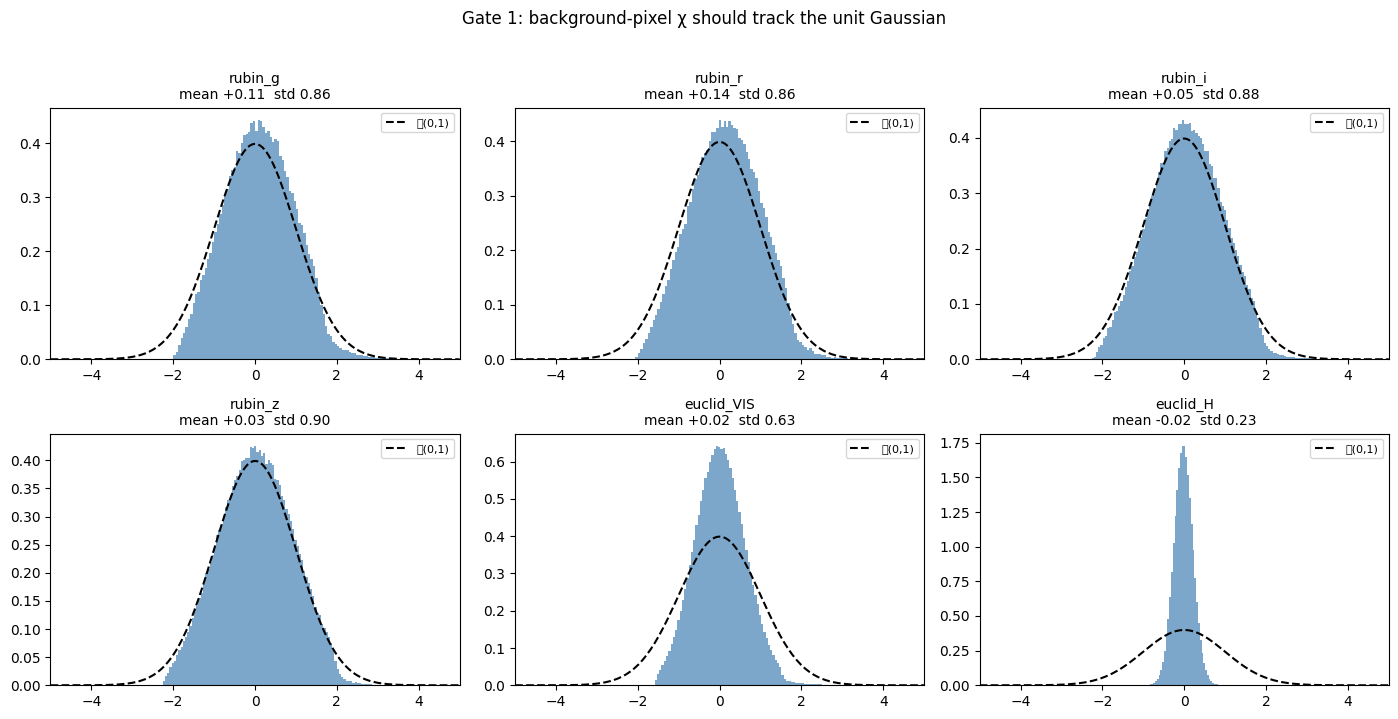

In [7]:
# Visual: background-χ histograms vs the unit Gaussian for a representative subset.
show = [b for b in ["rubin_g","rubin_r","rubin_i","rubin_z","euclid_VIS","euclid_H"] if b in loo]
fig, axes = plt.subplots(2, 3, figsize=(14, 7)); axes = axes.ravel()
xs = np.linspace(-5, 5, 200); gauss = np.exp(-xs**2/2)/np.sqrt(2*np.pi)
for ax, b in zip(axes, show):
    chi = loo[b]["resid"][background_mask(loo[b]["info"])]
    ax.hist(np.clip(chi, -5, 5), bins=120, density=True, alpha=0.7, color="steelblue")
    ax.plot(xs, gauss, "k--", lw=1.5, label="𝒩(0,1)")
    ax.set_title(f"{b}\nmean {chi.mean():+.2f}  std {chi.std():.2f}", fontsize=10)
    ax.set_xlim(-5, 5); ax.legend(fontsize=8)
fig.suptitle("Gate 1: background-pixel χ should track the unit Gaussian", y=1.02)
plt.tight_layout(); plt.show()

## 5. Look at the maps: truth / prediction / χ residual

For a few bands we show, side by side, the noise-normalized data, the model
prediction, and the χ residual on a **diverging** colormap centered at 0. Read the
residual panel as the anomaly map:

- flat grey everywhere ⇒ nothing surprising (model explains the band),
- a red/blue **dipole** at a source ⇒ sub-pixel centroid offset,
- a red **ring/donut** ⇒ PSF-width mismatch (core vs wings),
- extended correlated structure ⇒ a genuine anomaly (artifact or astrophysics).

We clip the χ display to ±5 so single-pixel noise doesn't dominate the stretch.

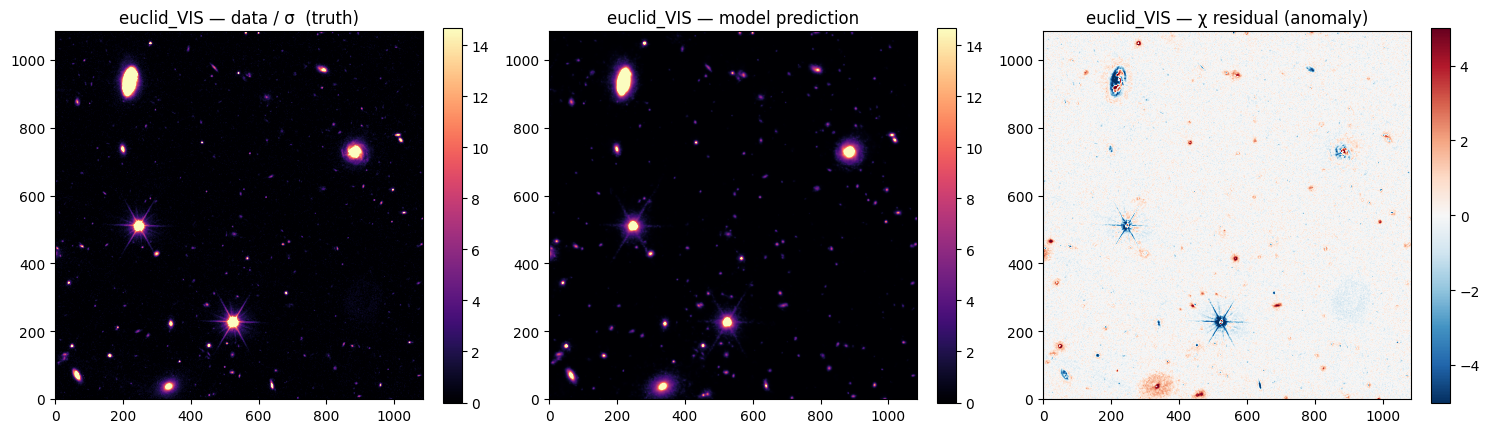

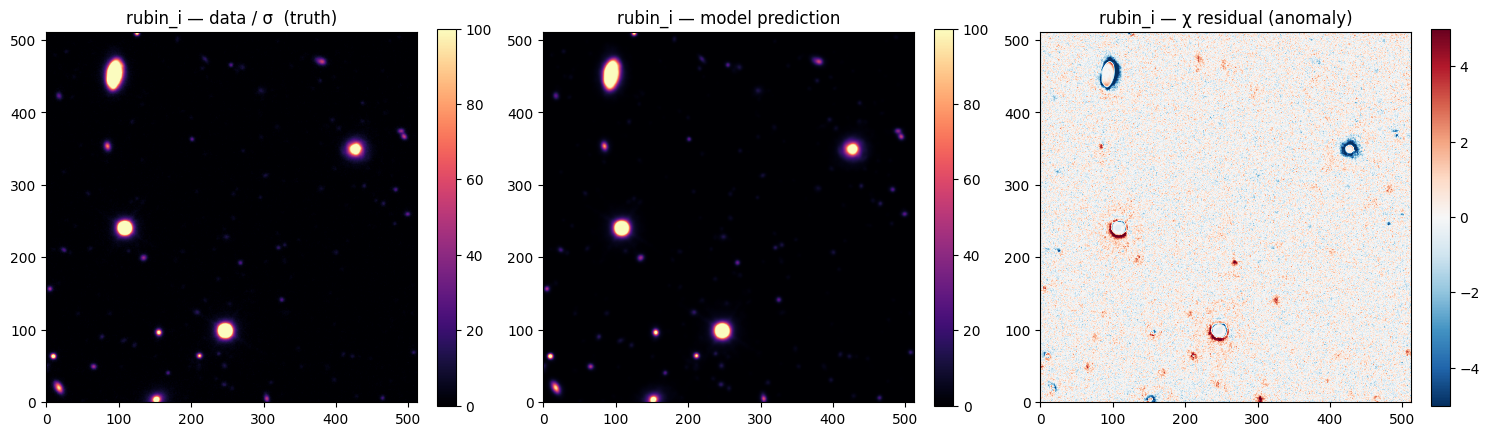

In [8]:
def show_band(b, chi_clip=5.0):
    d = loo[b]
    fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))
    # truth/pred share an asinh-ish percentile stretch
    vmax = np.nanpercentile(d["truth"], 99.5)
    for a, key, ttl in [(ax[0],"truth","data / σ  (truth)"), (ax[1],"pred","model prediction")]:
        im = a.imshow(d[key], origin="lower", cmap="magma", vmin=0, vmax=vmax)
        a.set_title(f"{b} — {ttl}"); plt.colorbar(im, ax=a, fraction=0.046)
    im = ax[2].imshow(np.clip(d["resid"], -chi_clip, chi_clip), origin="lower",
                      cmap="RdBu_r", norm=TwoSlopeNorm(0, -chi_clip, chi_clip))
    ax[2].set_title(f"{b} — χ residual (anomaly)"); plt.colorbar(im, ax=ax[2], fraction=0.046)
    plt.tight_layout(); plt.show()

for b in [bb for bb in ["euclid_VIS","rubin_i"] if bb in loo]:
    show_band(b)

## 6. Gate 2 + 3 — within-instrument vs cross-instrument channels

The design doc separates two anomaly channels because they catch different things:

- **Within-instrument** surprise (standard LOO, §3): a band disagrees with its *same-
  instrument* neighbours + the other instrument. Tends to flag single-band artifacts —
  diffraction spikes, persistence, cosmic rays, DCR, variability.
- **Cross-instrument** surprise: predict a band from the **other instrument only**
  (Euclid VIS from the 6 Rubin bands). This isolates inconsistency between two
  independently-calibrated instruments — the channel where resolution/morphology-driven
  science (blends, lenses, mergers) lives.

> **Caveat (stated honestly):** the model was trained dropping at most ~2 neighbour
> bands (p=0.25). Masking an *entire* instrument is out-of-distribution, so the
> cross-instrument χ will be larger and less perfectly calibrated than the standard
> channel. That is acceptable for a *relative* anomaly map (where does it spike?), but
> it is not a calibrated χ in the Gate-1 sense. We report it as a contrast map.

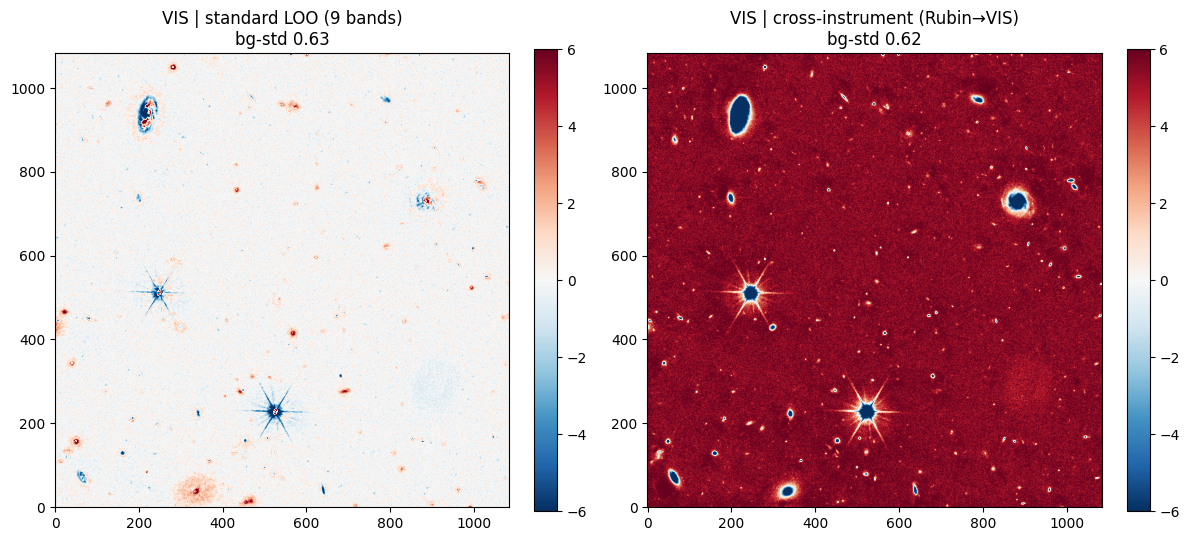

Interpretation: structure present in the cross-instrument panel but absent in the standard panel is information only the *other* instrument constrains.


In [9]:
# Cross-instrument: predict euclid_VIS from Rubin only (drop all Euclid context).
rubin_ctx = [b for b in RUBIN_BANDS if b in pool]
xinst_VIS = loo_reconstruct(pool, "euclid_VIS", rubin_ctx)

# Compare standard (9-band) vs cross-instrument (Rubin-only) χ for VIS.
std_VIS = loo["euclid_VIS"]
fig, ax = plt.subplots(1, 2, figsize=(12, 5.4))
for a, d, ttl in [(ax[0], std_VIS, "VIS | standard LOO (9 bands)"),
                  (ax[1], xinst_VIS, "VIS | cross-instrument (Rubin→VIS)")]:
    im = a.imshow(np.clip(d["resid"], -6, 6), origin="lower", cmap="RdBu_r",
                  norm=TwoSlopeNorm(0, -6, 6))
    a.set_title(f"{ttl}\nbg-std {d['resid'][background_mask(d['info'])].std():.2f}")
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()
print("Interpretation: structure present in the cross-instrument panel but absent in "
      "the standard panel is information only the *other* instrument constrains.")

## 7. Do known artifacts light up? (within-instrument check)

A quick, label-free version of Gate 2: the brightest correlated χ excursions should
sit on real structure (saturated cores, spikes, edges), not scatter randomly over sky.
We threshold |χ| and show where the high-χ pixels land, with the data underneath.

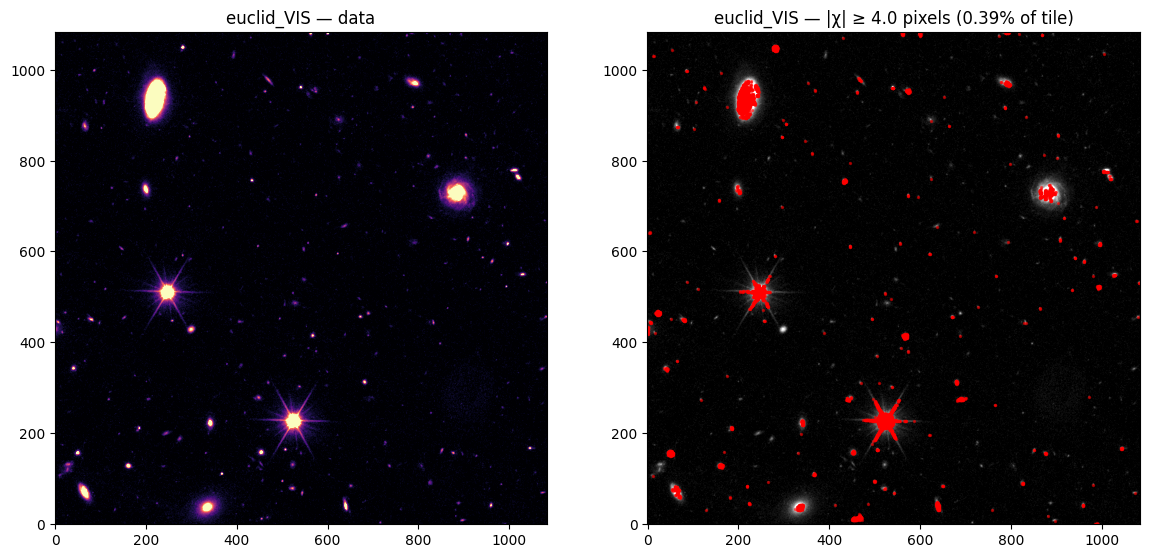

In [10]:
def highchi_overlay(b, chi_thr=4.0):
    d = loo[b]
    hot = np.abs(d["resid"]) >= chi_thr
    fig, ax = plt.subplots(1, 2, figsize=(12, 5.6))
    vmax = np.nanpercentile(d["truth"], 99.5)
    ax[0].imshow(d["truth"], origin="lower", cmap="magma", vmin=0, vmax=vmax)
    ax[0].set_title(f"{b} — data")
    ax[1].imshow(d["truth"], origin="lower", cmap="gray", vmin=0, vmax=vmax)
    ys, xs = np.where(hot)
    ax[1].scatter(xs, ys, s=2, c="red", alpha=0.5)
    ax[1].set_title(f"{b} — |χ| ≥ {chi_thr} pixels ({hot.mean()*100:.2f}% of tile)")
    plt.tight_layout(); plt.show()

highchi_overlay("euclid_VIS", chi_thr=4.0)

## 8. Per-source aggregation preview (toward the source-level score)

The pixel χ map becomes a *per-source* anomaly score by summing |χ| over each source's
footprint and normalizing (the flux-normalized aggregation from AS-Bridge, adopted in
the design doc to avoid the low-SNR noise-domination failure mode). Here we just preview
it: load the CenterNet detection catalog for this tile, drop a fixed aperture on the VIS
χ map at each source, and look at the **distribution** of per-source scores — most
sources should be quiet (score ≈ the noise expectation), with a tail of anomalous ones.

Detection labels are `d['labels'][tile_id] = (xy_norm[N,2], class[N])`, normalized to
[0,1] tile coordinates. We map them onto the VIS native grid. *(If the overlay looks
transposed/flipped, swap the x/y or flip an axis — orientation conventions between the
detector export and the raw tile are worth confirming before trusting absolute
positions; the score distribution itself is orientation-independent.)*

tile in catalog: True
468 detections on this tile


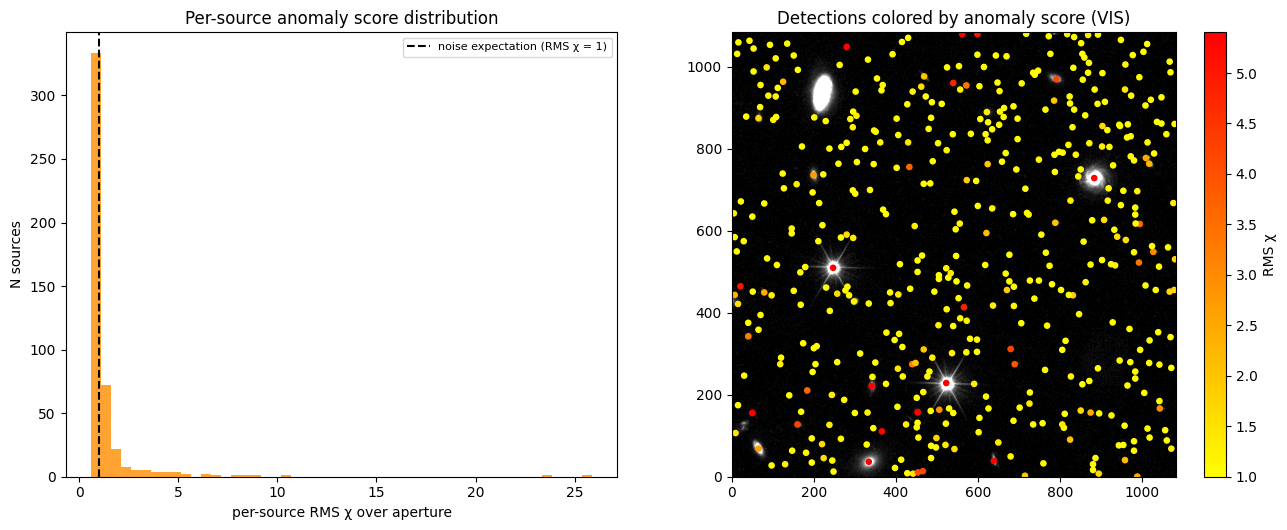

top-10 anomalous detections (idx, score, x, y):
  # 100  RMS χ 25.89  @ ( 523,  228)
  # 213  RMS χ 23.42  @ ( 247,  509)
  #  68  RMS χ 10.66  @ (  50,  155)
  # 450  RMS χ  9.07  @ ( 280, 1048)
  #  16  RMS χ  8.21  @ ( 639,   38)
  #  73  RMS χ  7.96  @ ( 453,  157)
  #  15  RMS χ  6.78  @ ( 334,   36)
  #  95  RMS χ  6.52  @ ( 341,  221)
  # 293  RMS χ  6.32  @ ( 884,  728)
  # 464  RMS χ  5.45  @ ( 562, 1079)


In [11]:
det_path = REPO / "data/detection_labels/centernet_v10_790_thresh03.pt"
det = torch.load(det_path, map_location="cpu", weights_only=False)
labels = det["labels"]
tid = sample["tile_id"]
print("tile in catalog:", tid in labels)

vis = loo["euclid_VIS"]
chi_vis = vis["resid"]
H, W = chi_vis.shape

if tid in labels:
    xy_norm = np.asarray(labels[tid][0], dtype=np.float32)  # (N,2) in [0,1]
    xs = np.clip((xy_norm[:, 0] * W).astype(int), 0, W - 1)
    ys = np.clip((xy_norm[:, 1] * H).astype(int), 0, H - 1)
    print(f"{len(xs)} detections on this tile")

    rad = 5  # native VIS px aperture (~0.5")
    def aperture_score(cx, cy, r=rad):
        y0, y1 = max(0, cy - r), min(H, cy + r + 1)
        x0, x1 = max(0, cx - r), min(W, cx + r + 1)
        patch = chi_vis[y0:y1, x0:x1]
        n = patch.size
        # flux-normalized: RMS chi over the aperture, minus the noise expectation (~1).
        return float(np.sqrt(np.mean(patch**2))), n

    scores = np.array([aperture_score(cx, cy)[0] for cx, cy in zip(xs, ys)])

    fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
    ax[0].hist(scores, bins=50, color="darkorange", alpha=0.8)
    ax[0].axvline(1.0, color="k", ls="--", label="noise expectation (RMS χ = 1)")
    ax[0].set_xlabel("per-source RMS χ over aperture"); ax[0].set_ylabel("N sources")
    ax[0].set_title("Per-source anomaly score distribution"); ax[0].legend(fontsize=8)

    vmax = np.nanpercentile(vis["truth"], 99.5)
    ax[1].imshow(vis["truth"], origin="lower", cmap="gray", vmin=0, vmax=vmax)
    sc = ax[1].scatter(xs, ys, c=scores, s=14, cmap="autumn_r",
                       vmin=1, vmax=np.percentile(scores, 98))
    plt.colorbar(sc, ax=ax[1], fraction=0.046, label="RMS χ")
    ax[1].set_title("Detections colored by anomaly score (VIS)")
    plt.tight_layout(); plt.show()

    top = np.argsort(scores)[::-1][:10]
    print("top-10 anomalous detections (idx, score, x, y):")
    for i in top:
        print(f"  #{i:4d}  RMS χ {scores[i]:5.2f}  @ ({xs[i]:4d}, {ys[i]:4d})")
else:
    print("tile not in detection catalog — skipping per-source preview")

## 9. Per-band calibration sweep (~30 tiles)

A single tile is an anecdote. To turn the §4 observation ("NISP background χ has
std ≪ 1") into a usable number, we sweep ~30 fully-populated 10-band tiles, measure the
background-χ mean/std per band per tile, and aggregate. Two products:

- a **calibration table** (median and inter-tile IQR of background-χ std per band) — is
  the deviation stable across the field, or tile-dependent noise?
- a **per-band renormalization factor** $s_b = 1/\mathrm{median}_t(\mathrm{std}_t)$, so that
  $\chi^{\text{cal}}_b = s_b\,\chi_b$ has unit background variance and anomaly scores are
  **comparable across bands**. This is the correction the single-tile run flagged is
  needed for NISP before its scores can sit on the same axis as Rubin/VIS.

The heavy loop is precomputed by `scratchpad/sweep_nb16.py` into
`io/_nb16_outputs/calibration_sweep.json`. The cell loads that sidecar if present and
otherwise recomputes inline (reusing `loo_reconstruct`/`background_mask` from above).

In [12]:
import json
SWEEP_JSON = REPO / "io/_nb16_outputs/calibration_sweep.json"
N_SWEEP = 30

if SWEEP_JSON.exists():
    sweep = json.loads(SWEEP_JSON.read_text())
    print(f"loaded cached sweep: {sweep['n_tiles']} tiles  ->  {SWEEP_JSON}")
else:
    print(f"no cached sweep; computing inline over up to {N_SWEEP} tiles (slow)...")
    per_tile = {b: {"mean": [], "std": []} for b in ALL_BANDS}
    used, n = [], 0
    for i in range(len(ds)):
        s = ds[i]; p = pool_of(s)
        if len(p) < len(ALL_BANDS):
            continue
        bnds = [b for b in ALL_BANDS if b in p]
        for b in bnds:
            d = loo_reconstruct(p, b, [c for c in bnds if c != b])
            chi = d["resid"][background_mask(d["info"])]
            per_tile[b]["mean"].append(float(chi.mean()))
            per_tile[b]["std"].append(float(chi.std()))
        used.append(s["tile_id"]); n += 1
        if n >= N_SWEEP:
            break
    sweep = {"n_tiles": n, "tiles": used, "info_frac": 0.50, "per_band": {}}
    for b in ALL_BANDS:
        st = np.array(per_tile[b]["std"]); mn = np.array(per_tile[b]["mean"])
        ms = float(np.median(st))
        sweep["per_band"][b] = {
            "mean_median": float(np.median(mn)), "std_median": ms,
            "std_iqr": float(np.percentile(st, 75) - np.percentile(st, 25)),
            "renorm_factor": float(1.0 / ms) if ms > 0 else float("nan"),
            "per_tile_mean": per_tile[b]["mean"], "per_tile_std": per_tile[b]["std"]}
    SWEEP_JSON.parent.mkdir(exist_ok=True)
    SWEEP_JSON.write_text(json.dumps(sweep, indent=2))
    print(f"computed and cached -> {SWEEP_JSON}")

loaded cached sweep: 30 tiles  ->  /home/shemmati/Work/Projects/JAISP/io/_nb16_outputs/calibration_sweep.json


In [13]:
pb = sweep["per_band"]
print(f"{'band':12s} {'mean(med)':>10s} {'std(med)':>9s} {'std IQR':>8s} {'renorm s_b':>11s}")
for b in ALL_BANDS:
    e = pb[b]
    flag = "" if 0.85 <= e["std_median"] <= 1.2 else "   <-- needs s_b"
    print(f"{b:12s} {e['mean_median']:+10.3f} {e['std_median']:9.3f} "
          f"{e['std_iqr']:8.3f} {e['renorm_factor']:11.3f}{flag}")
print(f"\n({sweep['n_tiles']} tiles, background = lowest-{int(sweep['info_frac']*100)}% InformationMap pixels)")

band          mean(med)  std(med)  std IQR  renorm s_b
rubin_u          -0.013     0.903    0.004       1.108
rubin_g          +0.107     0.862    0.022       1.160
rubin_r          +0.096     0.854    0.009       1.171
rubin_i          +0.043     0.880    0.006       1.137
rubin_z          +0.025     0.899    0.005       1.112
rubin_y          +0.006     0.908    0.015       1.102
euclid_VIS       +0.027     0.630    0.032       1.586   <-- needs s_b
euclid_Y         -0.024     0.238    0.072       4.200   <-- needs s_b
euclid_J         -0.027     0.231    0.100       4.336   <-- needs s_b
euclid_H         -0.028     0.235    0.108       4.259   <-- needs s_b

(30 tiles, background = lowest-50% InformationMap pixels)


/tmp/ipykernel_1836807/3735100674.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[b.replace("_", "\n") for b in ALL_BANDS], showfliers=False,


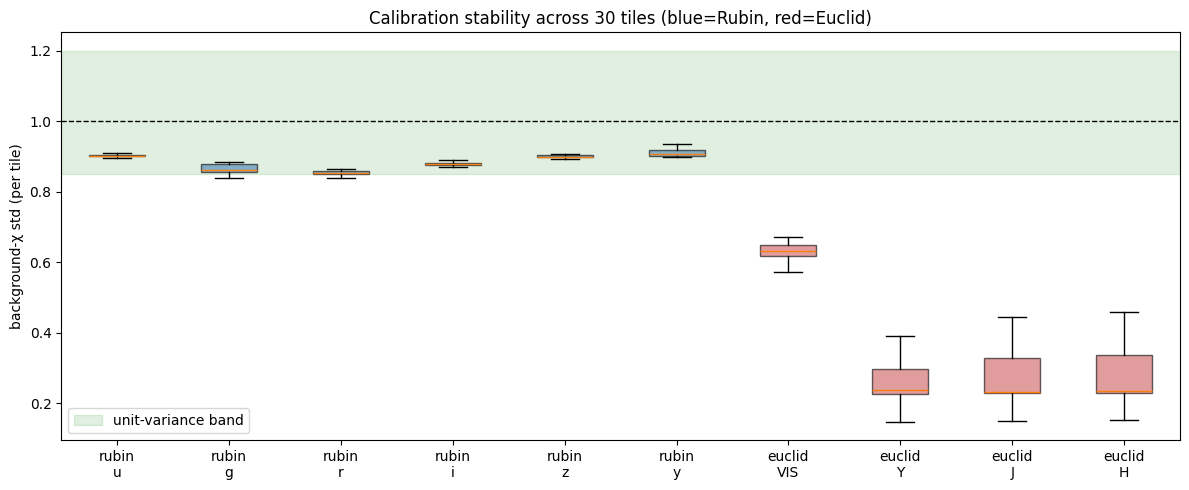

Per-band χ renormalization factors s_b (apply χ_cal = s_b · χ):
  rubin_u      1.108
  rubin_g      1.160
  rubin_r      1.171
  rubin_i      1.137
  rubin_z      1.112
  rubin_y      1.102
  euclid_VIS   1.586
  euclid_Y     4.200
  euclid_J     4.336
  euclid_H     4.259


In [14]:
# Per-band background-χ std across tiles: is the deviation stable (tight box) or noisy?
fig, ax = plt.subplots(figsize=(12, 5))
data = [pb[b]["per_tile_std"] for b in ALL_BANDS]
bp = ax.boxplot(data, labels=[b.replace("_", "\n") for b in ALL_BANDS], showfliers=False,
                patch_artist=True)
for patch, b in zip(bp["boxes"], ALL_BANDS):
    patch.set_facecolor("steelblue" if b.startswith("rubin") else "indianred")
    patch.set_alpha(0.6)
ax.axhspan(0.85, 1.2, color="green", alpha=0.12, label="unit-variance band")
ax.axhline(1.0, color="k", ls="--", lw=1)
ax.set_ylabel("background-χ std (per tile)")
ax.set_title(f"Calibration stability across {sweep['n_tiles']} tiles "
             "(blue=Rubin, red=Euclid)")
ax.legend(); plt.tight_layout(); plt.show()

renorm = {b: pb[b]["renorm_factor"] for b in ALL_BANDS}
print("Per-band χ renormalization factors s_b (apply χ_cal = s_b · χ):")
for b in ALL_BANDS:
    print(f"  {b:12s} {renorm[b]:.3f}")

## 10. What we learned & what's next

**If the three gates passed** (background χ ≈ 𝒩(0,1); artifacts produce correlated
high-|χ|; the cross-instrument channel carries structure the standard channel doesn't),
then the **anomaly engine works with zero training** — it is just calibrated inference
on the frozen v10 foundation, exactly as the design doc predicted.

**Immediate follow-ups (still cheap):**
- ✅ *Done in §9:* the ~30-tile calibration table and per-band renormalization factors
  $s_b$ (in `io/_nb16_outputs/calibration_sweep.json`). Apply $\chi^{\text{cal}}_b =
  s_b\,\chi_b$ so NISP scores are comparable to Rubin/VIS. **Use these factors in any
  source-level scoring below.**
- Promote the §8 preview to the real source-level score: replace the fixed aperture
  with the detection footprint, aggregate the **renormalized** per-band χ maps, and
  split into the **within-instrument** and **cross-instrument** channels of §6.
- Cross-match the top-scoring sources against known artifacts (MER `spurious_flag`,
  diffraction-spike masks) to start the false-positive audit (design doc §5.5).
- Diagnose *why* NISP std ≪ 1 (the open physics question): MER-mosaic correlated noise
  inflating the nominal `var` vs. the model predicting part of the background. The
  per-band $s_b$ is the empirical patch either way; the mechanism matters for whether
  the same factor transfers to EDF-S.

**Then the bridge to the paper:** this χ residual is one half of the §4 fusion plot —
the *catalog-failure* axis. Pair it with the sufficiency probe (notebook 05 upgraded to
conditional V-information) to test whether the information the catalog discards
concentrates on exactly these high-χ sources.

*This notebook writes no checkpoints and mutates no data; it is safe to re-run.*